In [ ]:
import pandas as pd
import numpy as np
import tensorflow.keras as tf
from tensorflow.keras import layers, models
from google.colab import drive
drive.mount('/content/drive')
data_path='/content/drive/MyDrive/Test'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_ds= tf.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=1,
    image_size=(28, 28),
    batch_size=32
)

Found 6001 files belonging to 10 classes.
Using 4801 files for training.


In [ ]:
val_ds = tf.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=1,
    image_size=(28, 28),
    batch_size=32
)

Found 6001 files belonging to 10 classes.
Using 1200 files for validation.


In [ ]:
normalization_layer = layers.Rescaling(1./255)

In [ ]:
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
model= tf.models.Sequential()
model.add(tf.layers.Flatten())
model.add(tf.layers.Dense(784, activation='relu'))
model.add(tf.layers.Dense(10, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs= 10)

Epoch 1/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 30s 189ms/step - accuracy: 0.4568 - loss: 1.6090 - val_accuracy: 0.5433 - val_loss: 1.2786
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 38s 167ms/step - accuracy: 0.7290 - loss: 0.8435 - val_accuracy: 0.6325 - val_loss: 1.0758
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 27s 178ms/step - accuracy: 0.8704 - loss: 0.4565 - val_accuracy: 0.6842 - val_loss: 0.9591
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 40s 175ms/step - accuracy: 0.9429 - loss: 0.2578 - val_accuracy: 0.7192 - val_loss: 0.9211
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 26s 174ms/step - accuracy: 0.9915 - loss: 0.0989 - val_accuracy: 0.7292 - val_loss: 0.9119
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 26s 174ms/step - accuracy: 0.9988 - loss: 0.0452 - val_accuracy: 0.7258 - val_loss: 0.9705
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 26s 170ms/step - accuracy: 0.9988 - loss: 0.0290 - val_accuracy: 0.7308 - val_loss: 0.9730
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 26s 170ms/step - accuracy: 0.9998 - loss: 0

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │     1,844,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 20)             │        15,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,581,358 (21.29 MB)

 Trainable params: 1,860,452 (7.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,720,906 (14.19 MB)

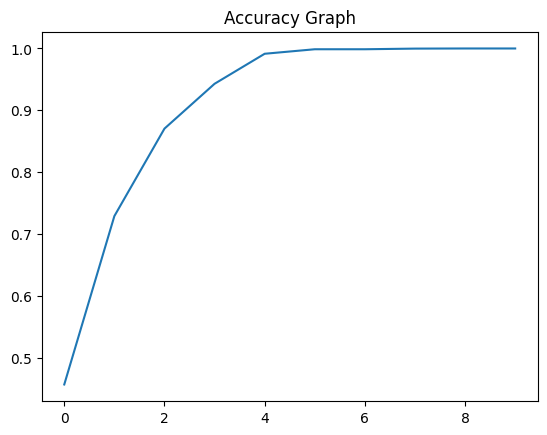

In [ ]:
import matplotlib.pyplot as plt
plt.title('Accuracy Graph')
plt.plot(history.history['accuracy'])
plt.show()

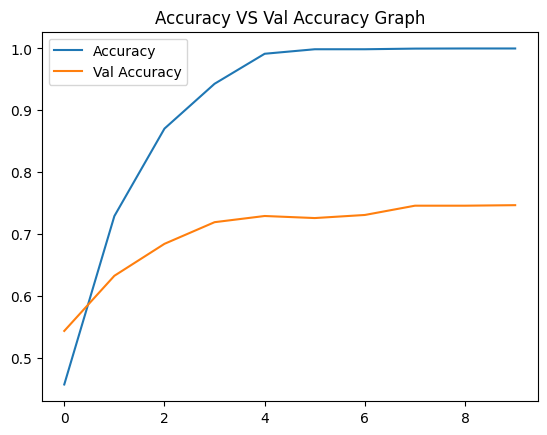

In [ ]:
plt.title('Accuracy VS Val Accuracy Graph')
plt.plot(history.history['accuracy'], label=('Accuracy'))
plt.plot(history.history['val_accuracy'], label=('Val Accuracy'))
plt.legend()
plt.show()

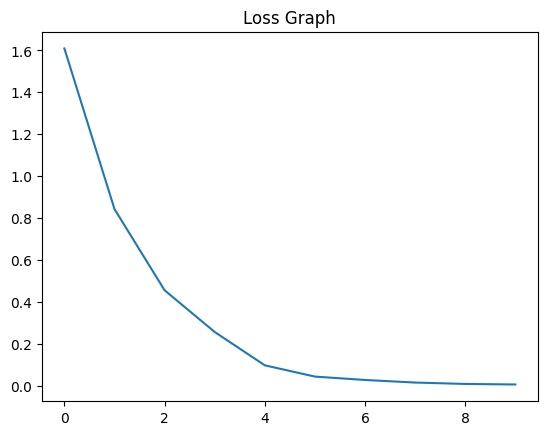

In [ ]:
plt.title('Loss Graph')
plt.plot(history.history['loss'])
plt.show()

In [ ]:
img_path = "/content/drive/MyDrive/test_image.png"

img = load_img(img_path, target_size=(28, 28))








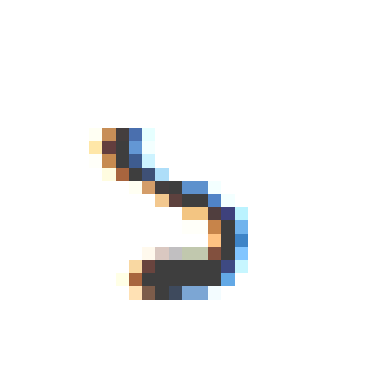

In [ ]:

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:

img_array = img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:

prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


In [ ]:

predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

In [ ]:

print("Probabilities:")
print(prediction)

Probabilities:
[[9.9999833e-01 1.7098777e-06 1.0013988e-31 0.0000000e+00 9.0906602e-29
  3.7278583e-12 5.4029724e-37 4.1260253e-23 2.2633713e-21 6.5824175e-29
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]]


In [ ]:
print(prediction.round())

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
